# Analiza podatkov

In [4]:

import pandas as pd
import matplotlib.pyplot as plt
pd.options.display.max_rows = 20
name = "Feinberg"
goals = pd.read_csv(f'{name}.csv', index_col='id')
goals['draft_ratio'] = round(100*goals['drafted'] / goals['choice'])
goals['win_ratio'] = round(100*goals['completed'] / (goals['completed'] + goals['lost']))


**1) Cilji, ki jih igralec najpogosteje zmaga**

In [5]:

goals[goals['completed'] + goals['lost'] >= 3].sort_values(by='win_ratio', ascending=False)[['name','win_ratio']].head(20).rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)'})


,Ime,Zmagan (%)
id,,
20,Brew a Potion of Poison,100.0
21,Brew a Potion of Swiftness,100.0
23,Brew a Potion of Weakness,100.0
31,Craft 100 Unique Items,100.0
35,Die by falling in Void,100.0
72,Enter The End,100.0
125,Kill Warden,100.0
81,Find a Stronghold,100.0
73,Explode End Crystal,100.0


In [6]:
goals[goals['completed'] + goals['lost'] >= 3].sort_values(by='win_ratio', ascending=True)[['name','win_ratio']].head(20).rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)'})

,Ime,Zmagan (%)
id,,
288,Tame a Parrot,0.0
359,Wear Red Leather Boots,0.0
163,Obtain 64 Blue Concrete,0.0
176,Obtain 64 White Concrete,0.0
41,Die to Berry Bush,20.0
206,Obtain Blue Glazed Terracotta,25.0
289,Tame a Wolf,25.0
34,Die by Drowning,26.0
198,Obtain all Diamond Tools,27.0


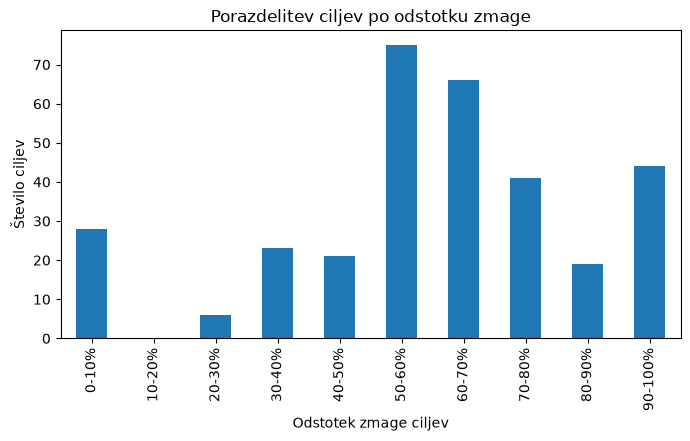

In [7]:
tenths = [0]*10

    
for _, row in goals.iterrows():
    item = row['win_ratio']
    if item == 100:
        tenths[9]+=1
    elif not pd.isna(item):
        tenths[int(item // 10)] += 1



oznake = ['0-10%','10-20%','20-30%','30-40%','40-50%','50-60%','60-70%','70-80%','80-90%','90-100%']

desetine_graf = pd.Series(tenths, index=oznake)

desetine_graf.plot(
    title='Porazdelitev ciljev po odstotku zmage',
    kind='bar',
    figsize=(8, 4),
    xlabel='Odstotek zmage ciljev',
    ylabel='Število ciljev',
)


plt.show()

**2) Najpogosteje in najredkeje izbrani cilji**


In [9]:



goals[goals['choice'] >= 5].sort_values(by='draft_ratio', ascending=False)[['name','draft_ratio','win_ratio']].head(20).rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)'})




,Ime,Izbran (%),Zmagan (%)
id,,,
31,Craft 100 Unique Items,100.0,100.0
261,Obtain Smooth Quartz Stairs,93.0,89.0
58,Eat 20 Unique Food,92.0,64.0
158,Obtain 10 Advancements,91.0,70.0
80,Fill Inventory with unique items,89.0,89.0
113,Kill Red Sheep,88.0,62.0
160,Obtain 30 Advancements,86.0,100.0
204,Obtain Bell,83.0,55.0
30,Craft 50 Unique Items,83.0,88.0


In [11]:



goals[goals['choice'] >= 5].sort_values(by='draft_ratio', ascending=True)[['name','draft_ratio','win_ratio']].head(20).rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)'})




,Ime,Izbran (%),Zmagan (%)
id,,,
6,Breed Camels,0.0,100.0
9,Breed Foxes,0.0,NaN
48,Die to Pufferfish,0.0,100.0
37,Die by Freezing,0.0,0.0
44,Die to Falling Stalactite,0.0,67.0
47,Die to Polar Bear,0.0,50.0
103,Kill all Raid Mobs,0.0,NaN
166,Obtain 64 Gray Concrete,0.0,50.0
288,Tame a Parrot,0.0,0.0


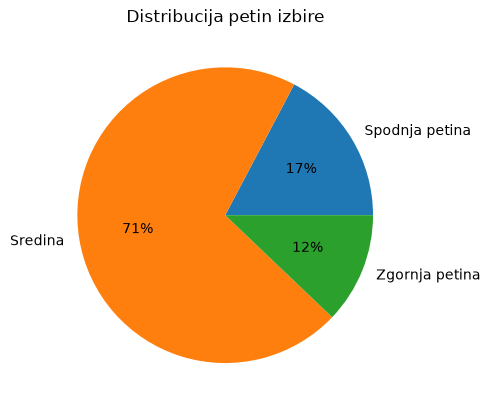

In [12]:

count_low = (goals['draft_ratio'] <= 20).sum()
count_high = (goals['draft_ratio'] >= 80).sum()
count_mid = ((goals['draft_ratio']>20) & (goals['draft_ratio']<80)).sum()
count_sum=count_low+count_high+count_mid


data = pd.DataFrame({
    'Name': ['Spodnja petina'] + ['Sredina'] + ['Zgornja petina'] ,
    'Percentage': [
        count_low,
        count_mid,
        count_high,
    ],
})


data.groupby('Name')['Percentage'].sum().plot(
    kind='pie',
    autopct='%1.0f%%',
    ylabel='',
    legend=False,
    title='Distribucija petin izbire',
)

plt.show()

**3) Učinkovitost izbire**

In [14]:
goals['draft_efficiency'] = (goals['draft_ratio'] + goals['win_ratio'])/2
goals[goals['draft_efficiency'].notnull() & (goals['appeared']>= 3)].sort_values(by=['draft_efficiency'], ascending=[False])
goals[goals['appeared']>= 5].sort_values(by='draft_efficiency', ascending=False)[['name','draft_ratio','win_ratio', 'draft_efficiency']].head(20).rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'win_ratio': 'Zmagan (%)', 'draft_efficiency': 'Učinkovitost izbire (%)'})


,Ime,Izbran (%),Zmagan (%),Učinkovitost izbire (%)
id,,,,
31,Craft 100 Unique Items,100.0,100.0,100.0
160,Obtain 30 Advancements,86.0,100.0,93.0
261,Obtain Smooth Quartz Stairs,93.0,89.0,91.0
80,Fill Inventory with unique items,89.0,89.0,89.0
72,Enter The End,76.0,100.0,88.0
21,Brew a Potion of Swiftness,72.0,100.0,86.0
30,Craft 50 Unique Items,83.0,88.0,85.5
11,Breed Goats,67.0,100.0,83.5
151,Obtain 3 types of Horse Armor,79.0,84.0,81.5


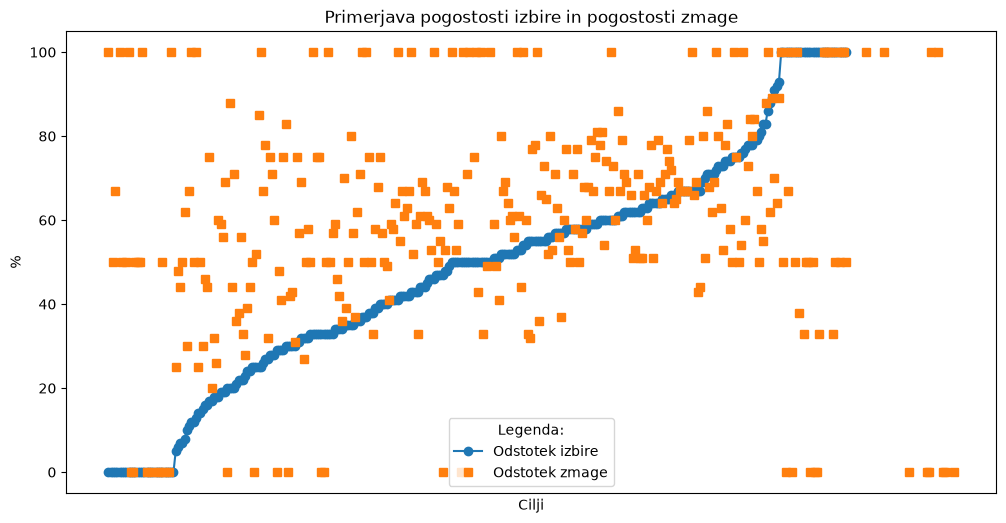

In [15]:

draft_sorted = goals.sort_values(by='draft_ratio').reset_index(drop=True)
x_axis = draft_sorted.index
plt.figure(figsize=(12, 6))

plt.plot(
    x_axis,
    draft_sorted['draft_ratio'],
    marker='o',
    linestyle='-',
    color='tab:blue',
    label='Odstotek izbire',
)

plt.plot(
    x_axis,
    draft_sorted['win_ratio'],
    marker='s',
    linestyle='None',
    color='tab:orange',
    label='Odstotek zmage',
)
plt.xticks([])
plt.title('Primerjava pogostosti izbire in pogostosti zmage')
plt.xlabel('Cilji')
plt.ylabel('%')
plt.legend(title='Legenda:')
plt.show()

**4) Najredkeje in najpogosteje opravljeni cilji**

In [17]:
goals['completion_ratio'] = round(100*(goals['completed'] + goals['lost']) / goals['appeared'])
goals[goals['appeared']>= 5].sort_values(by='completion_ratio', ascending=False)[['name','win_ratio','completion_ratio']].head(20).rename(columns={'name': 'Ime', 'win_ratio': 'Zmagan (%)', 'completion_ratio': 'Opravljen (%)'})


,Ime,Zmagan (%),Opravljen (%)
id,,,
7,Breed Chickens,55.0,100.0
8,Breed Cows,58.0,100.0
34,Die by Drowning,26.0,100.0
29,Craft 20 Unique Items,78.0,100.0
33,Decorate Shield with Banner,53.0,100.0
80,Fill Inventory with unique items,89.0,100.0
79,Fill Composter and get Bone Meal,60.0,100.0
75,Fill a Decorated Pot,49.0,100.0
77,Fill Campfire with 4 Food Items,59.0,100.0


In [ ]:
goals[goals['appeared']>= 5].sort_values(by='completion_ratio', ascending=True)[['name','draft_ratio','completion_ratio']].head(20).rename(columns={'name': 'Ime', 'draft_ratio': 'Izbran (%)', 'completion_ratio': 'Opravljen (%)'})

,Ime,Izbran (%),Opravljen (%)
id,,,
306,Wear a Chain Armor Piece,62.0,0.0
373,Wear Full Diamond Armor,37.0,5.0
4,Breed 8 Unique Animals,47.0,8.0
271,Put Wolf Armor on Wolf,30.0,9.0
35,Die by falling in Void,41.0,17.0
92,Get on Nether Roof,20.0,21.0
264,Obtain Suspicious Sand/Gravel,25.0,22.0
131,Leash 8 unique Mobs at once,59.0,23.0
18,Brew a Potion of Healing,42.0,25.0


: 

**5) Analiza igralca Feinberg**